# Statistical comparison of samples with stat_tool

## This notebook illustates how to perform statistical tests and other analyses for comparing samples with stat_tool.comparison

Load data sets (meri1.his to meri3.his)    

In [1]:
from openalea.stat_tool import (
    get_shared_data,
    Histogram,
    Vectors,
    VectorDistance,
    SelectVariable
)

from openalea.stat_tool.comparison import (
    ComparisonTest, 
    Compare
)

from openalea.stat_tool.output import Plot

import numpy as np

meri1 = Histogram(get_shared_data("meri1.his"))
meri2 = Histogram(get_shared_data("meri2.his"))
meri3 = Histogram(get_shared_data("meri3.his"))

Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/stat_tool/build
Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/sequence_analysis/build


Exploratory analysis suggests that meri1 is globally larger than meri2

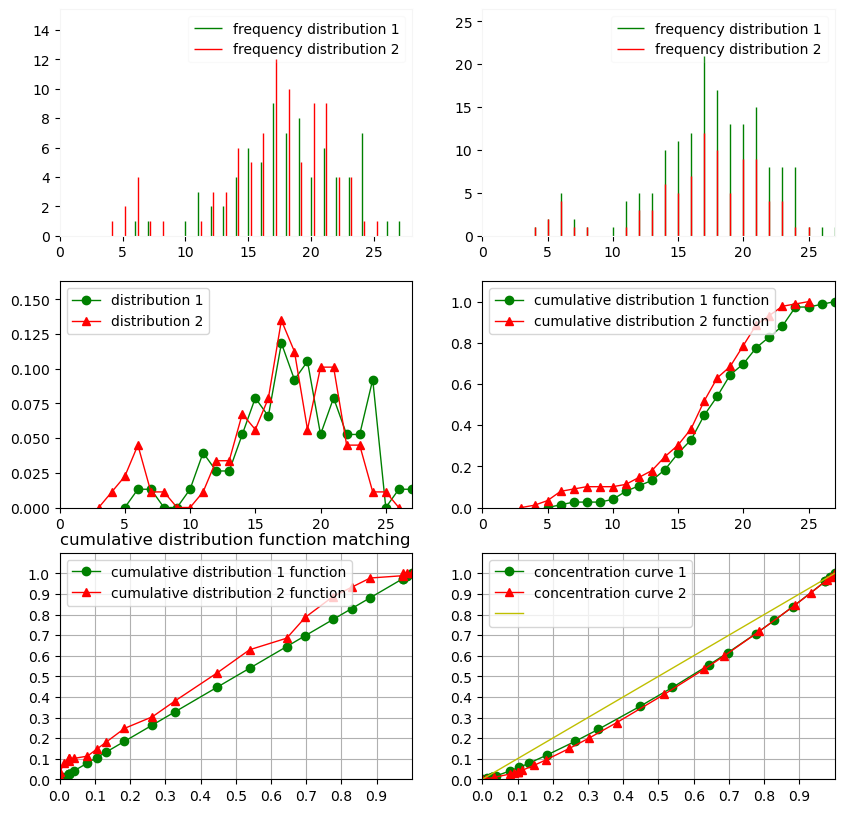

In [2]:
Plot(meri1, meri2)

## Statistical tests for comparing samples

**Student's test for comparing means in Gaussian samples**   
Null hypothesis: sample 1 and sample 2 have the same means

In [3]:
print(ComparisonTest("T", meri1, meri2))

two-sided t-test (162 degrees of freedom)
t-value: 1.87611   critical probability: 0.0624397
reference t-value: 1.97472   reference critical probability: 0.05



Alternative syntax, object-oriented:

In [4]:
print(meri1.t_comparison(meri2))

two-sided t-test (162 degrees of freedom)
t-value: 1.87611   critical probability: 0.0624397
reference t-value: 1.97472   reference critical probability: 0.05



show sample means

In [5]:
meri1.mean, meri2.mean

(18.026315789473685, 16.707865168539325)

**Wilcoxon-Mann-Whitney nonparametric test for comparing means in two samples**   
Null hypothesis: sample 1 and sample 2 have the same means.

In [6]:
print(ComparisonTest("W", meri1, meri2))

two-sided Wilcoxon-Mann-Whitney test
standard normal value: 1.45438   critical probability: 0.145841
reference standard normal value: 1.95996   reference critical probability: 0.05
P(X1 < X2) = 0.400651   P(X1 = X2) = 0.0674157   P(X1 > X2) = 0.531934



In [7]:
print(meri1.wmw_comparison(meri2))

two-sided Wilcoxon-Mann-Whitney test
standard normal value: 1.45438   critical probability: 0.145841
reference standard normal value: 1.95996   reference critical probability: 0.05
P(X1 < X2) = 0.400651   P(X1 = X2) = 0.0674157   P(X1 > X2) = 0.531934



**Fisher's test for comparing variances in Gaussian samples**   
Null hypothesis: sample 1 and sample 2 have the same variances.

In [8]:
print(ComparisonTest("F", meri1, meri2))

F-test (88 degrees of freedom, 75 degrees of freedom)
F-value: 1.21097   critical probability: 0.19769
reference F-value: 1.44897   reference critical probability: 0.05



In [9]:
print(meri1.f_comparison(meri2))

F-test (88 degrees of freedom, 75 degrees of freedom)
F-value: 1.21097   critical probability: 0.19769
reference F-value: 1.44897   reference critical probability: 0.05



show sample standard deviations

In [10]:
np.sqrt(meri1.variance), np.sqrt(meri2.variance)

(np.float64(4.295652637137618), np.float64(4.727103300963237))

## Using Compare to compare more than 2 samples.    
This function prints each histogram separately, then using common rows and
then prints dissimilarity measures between histograms. If the variables are numeric, 
an ANOVA is performed, as well as Fisher F-tests to compare variances.   
The dissimilarity measure $d(h,h')$ between histograms $h$ and $h'$, seen as arrays of relative frequencies, 
globally writes as:
$$
d(h,h') = \sum\limits_k \sum\limits_{m > k} \rho(h[k] * h'[m] - h[m] * h'[k], m-k)
$$
where 
$$
\rho(h[k] * h'[m] - h[m] * h'[k], m-k) = 
\left\lbrace 
\begin{array}{l}
|h[k] * h'[m] - h[m] * h'[k]| \textrm{ if the variable is ordinal, with} d(h,h') = -d(h',h) \\
h[k] * h'[m] - h[m] * h'[k] \textrm{ if the variable is symbolic, with } d(h,h') = d(h',h)\\
(m-k)(h[k] * h'[m] - h[m] * h'[k]) \textrm{ if the variable is numeric, with }  d(h,h') = -d(h',h)\\
\end{array}
\right.
$$


In [11]:
compare_numeric = Compare(meri1, meri2, meri3, "NUMERIC")

In [12]:
print(compare_numeric)

frequency distribution 1 - sample size: 76
mean: 18.0263   median: 18   mode: 17
variance: 18.4526   standard deviation: 4.29565   lower quartile: 15   upper quartile: 21
coefficient of skewness: -0.370952   coefficient of kurtosis: -0.0181747
mean absolute deviation: 3.3705   coefficient of concentration: 0.132789
information: -207.685 (-2.7327)

frequency distribution 2 - sample size: 89
mean: 16.7079   median: 17   mode: 17
variance: 22.3455   standard deviation: 4.7271   lower quartile: 15   upper quartile: 20
coefficient of skewness: -0.977759   coefficient of kurtosis: 0.540819
mean absolute deviation: 3.55208   coefficient of concentration: 0.151923
information: -242.014 (-2.71926)

frequency distribution 3 - sample size: 120
mean: 12.9417   median: 14   mode: 15
variance: 14.9125   standard deviation: 3.86168   lower quartile: 10   upper quartile: 16
coefficient of skewness: -0.563081   coefficient of kurtosis: -0.649252
mean absolute deviation: 3.14347   coefficient of concent

An abbreviated version can be used for variable type: N, O or S.

In [13]:
assert(compare_numeric == Compare(meri1, meri2, meri3, "N"))

In [14]:
print(Compare(meri1, meri2, meri3, "ORDINAL"))

frequency distribution 1 - sample size: 76
mean: 18.0263   median: 18   mode: 17
variance: 18.4526   standard deviation: 4.29565   lower quartile: 15   upper quartile: 21
coefficient of skewness: -0.370952   coefficient of kurtosis: -0.0181747
mean absolute deviation: 3.3705   coefficient of concentration: 0.132789
information: -207.685 (-2.7327)

frequency distribution 2 - sample size: 89
mean: 16.7079   median: 17   mode: 17
variance: 22.3455   standard deviation: 4.7271   lower quartile: 15   upper quartile: 20
coefficient of skewness: -0.977759   coefficient of kurtosis: 0.540819
mean absolute deviation: 3.55208   coefficient of concentration: 0.151923
information: -242.014 (-2.71926)

frequency distribution 3 - sample size: 120
mean: 12.9417   median: 14   mode: 15
variance: 14.9125   standard deviation: 3.86168   lower quartile: 10   upper quartile: 16
coefficient of skewness: -0.563081   coefficient of kurtosis: -0.649252
mean absolute deviation: 3.14347   coefficient of concent

In [15]:
print(Compare(meri1, meri2, meri3, "SYMBOLIC"))

frequency distribution 1 - sample size: 76
information: -207.685 (-2.7327)

frequency distribution 2 - sample size: 89
information: -242.014 (-2.71926)

frequency distribution 3 - sample size: 120
information: -307.094 (-2.55912)

   | frequency distribution 1 | frequency distribution 2 | frequency distribution 3 | cumulative distribution 1 function | cumulative distribution 2 function | cumulative distribution 3 function
 0   0   0   0          0          0          0
 1   0   0   0          0          0          0
 2   0   0   0          0          0          0
 3   0   0   0          0          0          0
 4   0   1   0          0   0.011236          0
 5   0   2   4          0  0.0337079  0.0333333
 6   1   4   8  0.0131579  0.0786517        0.1
 7   1   1   6  0.0263158  0.0898876       0.15
 8   0   1   5  0.0263158   0.101124   0.191667
 9   0   0   3  0.0263158   0.101124   0.216667
10   1   0   5  0.0394737   0.101124   0.258333
11   3   1   5  0.0789474    0.11236        0.

## Using Compare to standardize vectors in distance computations

The type VECTOR_DISTANCE implements standardization procedures. The objective
of standardization is to avoid the dependence on the variable type (chosen among
symbolic, ordinal, numeric and circular) and, for numeric variables, on the choice of
the measurement units by converting the original variables to unitless variables. 
This can be used for hierarchical clustering, see clustering.ipynb.

In [16]:
vec10 = Vectors(get_shared_data("chene_sessile.vec"))
# Discard variables 1, 3 and 6
vec15 = SelectVariable(vec10, [1, 3, 6], Mode="Reject")
matrix10 = Compare(vec15, VectorDistance("N", "N", "N"))
matrix10